<a href="https://colab.research.google.com/github/Yashmitha22/ML_projects/blob/main/exam_malpractice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.1 MB/s eta 0:00:00


In [4]:
import os

# Replace the path below with your actual dataset folder
dataset_path = "/content/drive/MyDrive/exam_dataset"

# List contents
print(os.listdir(dataset_path))


['README.dataset.txt', 'README.roboflow.txt', 'data.yaml', 'valid', 'test', 'train']


In [5]:
import os

train_labels = '/content/drive/MyDrive/exam_dataset/train/labels'
train_images = '/content/drive/MyDrive/exam_dataset/train/images'

label_files = {os.path.splitext(f)[0] for f in os.listdir(train_labels)}
image_files = {os.path.splitext(f)[0] for f in os.listdir(train_images)}

missing_labels = image_files - label_files
missing_images = label_files - image_files

print(f"Missing label files: {len(missing_labels)}")
print(f"Missing image files: {len(missing_images)}")

if missing_labels:
    print("\n⚠️ These images don’t have label files:")
    print(list(missing_labels)[:10])  # show first 10

Missing label files: 0
Missing image files: 0


In [7]:
import os
import random
import shutil
from tqdm import tqdm

# paths
base_dir = "/content/drive/MyDrive/exam_dataset"
train_images = os.path.join(base_dir, "train/images")
train_labels = os.path.join(base_dir, "train/labels")
valid_images = os.path.join(base_dir, "valid/images")
valid_labels = os.path.join(base_dir, "valid/labels")

# create folders if not exist
os.makedirs(valid_images, exist_ok=True)
os.makedirs(valid_labels, exist_ok=True)

# supported image formats
valid_exts = ('.jpg', '.jpeg', '.png')

# get all valid image files only
image_files = [f for f in os.listdir(train_images) if f.lower().endswith(valid_exts)]

# shuffle for randomness
random.shuffle(image_files)

# 20% split
split_index = int(0.8 * len(image_files))
val_files = image_files[split_index:]

print(f"Copying {len(val_files)} files to validation set...")

copied = 0
skipped = 0

for img_file in tqdm(val_files):
    img_path = os.path.join(train_images, img_file)

    # robust label matching
    label_file = os.path.splitext(img_file)[0] + ".txt"
    label_path = os.path.join(train_labels, label_file)

    try:
        # copy image
        shutil.copy2(img_path, os.path.join(valid_images, img_file))

        # copy label if exists
        if os.path.exists(label_path):
            shutil.copy2(label_path, os.path.join(valid_labels, label_file))
            copied += 1
        else:
            print(f"⚠️ Label not found for: {img_file}")
            skipped += 1

    except Exception as e:
        print(f"❌ Error with {img_file}: {e}")
        skipped += 1

print("\n✅ Split complete!")
print(f"✔️ Successfully copied: {copied}")
print(f"⚠️ Skipped: {skipped}")

Copying 148 files to validation set...


100%|██████████| 148/148 [01:04<00:00,  2.29it/s]


✅ Split complete!
✔️ Successfully copied: 148
⚠️ Skipped: 0


In [12]:
from ultralytics import YOLO

model = YOLO('yolov8s.pt')

model.train(
    data='/content/drive/MyDrive/exam_dataset/data.yaml',
    epochs=50,
    imgsz=640,
    batch=8,
    name='invigilo_yolov8',
    patience=10
)

Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/exam_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=invigilo_yolov84, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 7])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b4fb3c51850>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
  

In [13]:
!ls /content/runs/detect/

invigilo_yolov8  invigilo_yolov82  invigilo_yolov83  invigilo_yolov84


In [14]:
!ls /content/runs/train/

ls: cannot access '/content/runs/train/': No such file or directory


In [15]:
!ls /content/runs/detect/invigilo_yolov8/


args.yaml  weights


In [16]:
!ls /content/runs/detect/invigilo_yolov8/weights/

Using folder: /content/runs/detect/invigilo_yolov84


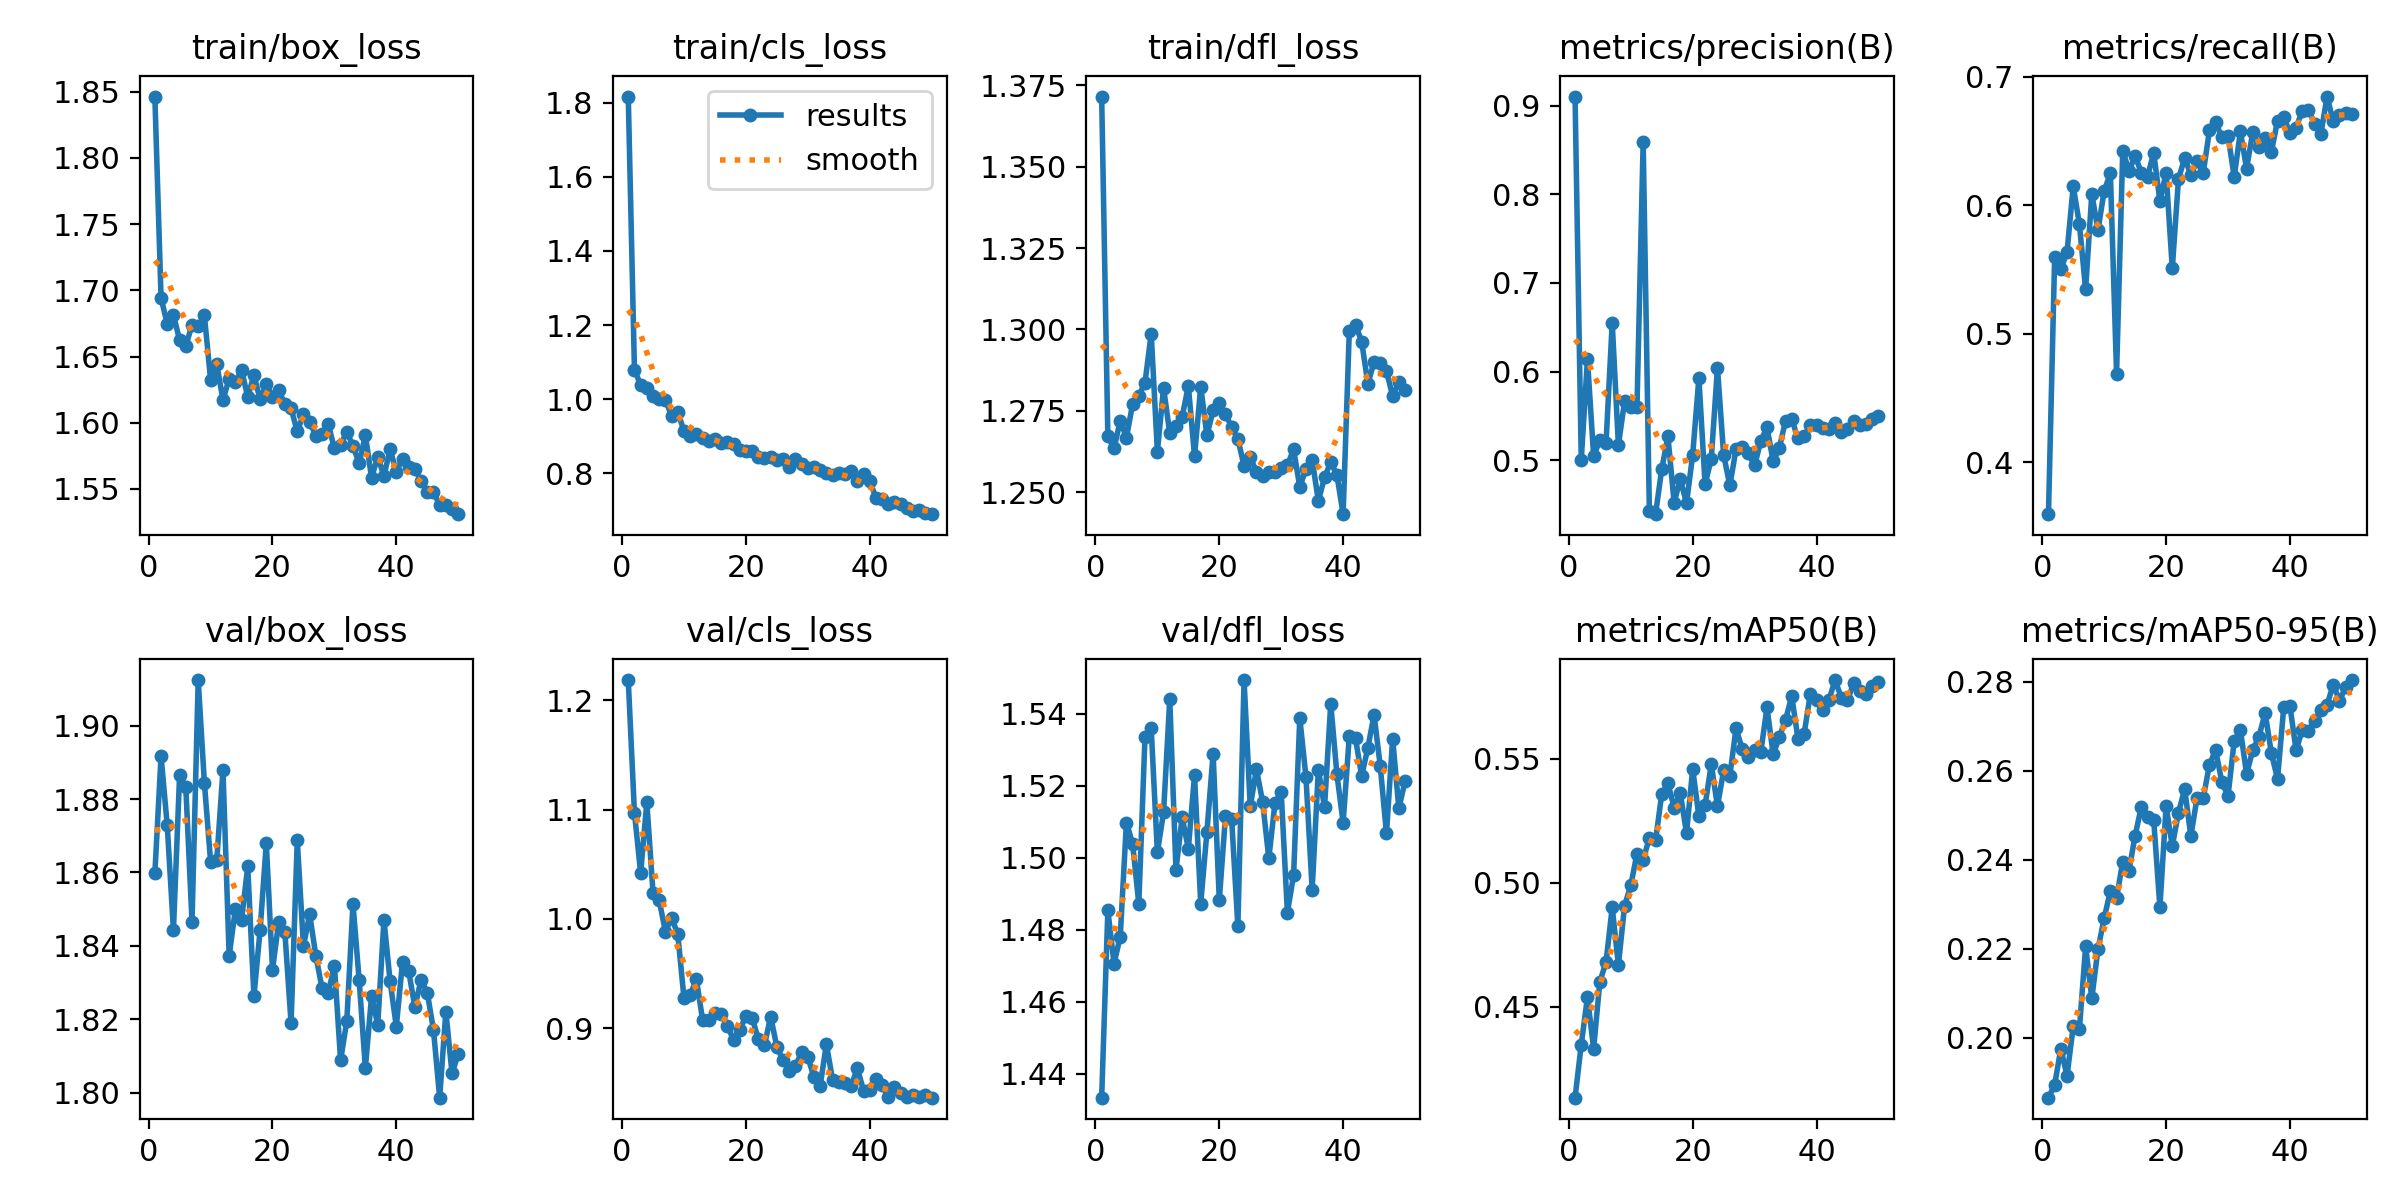

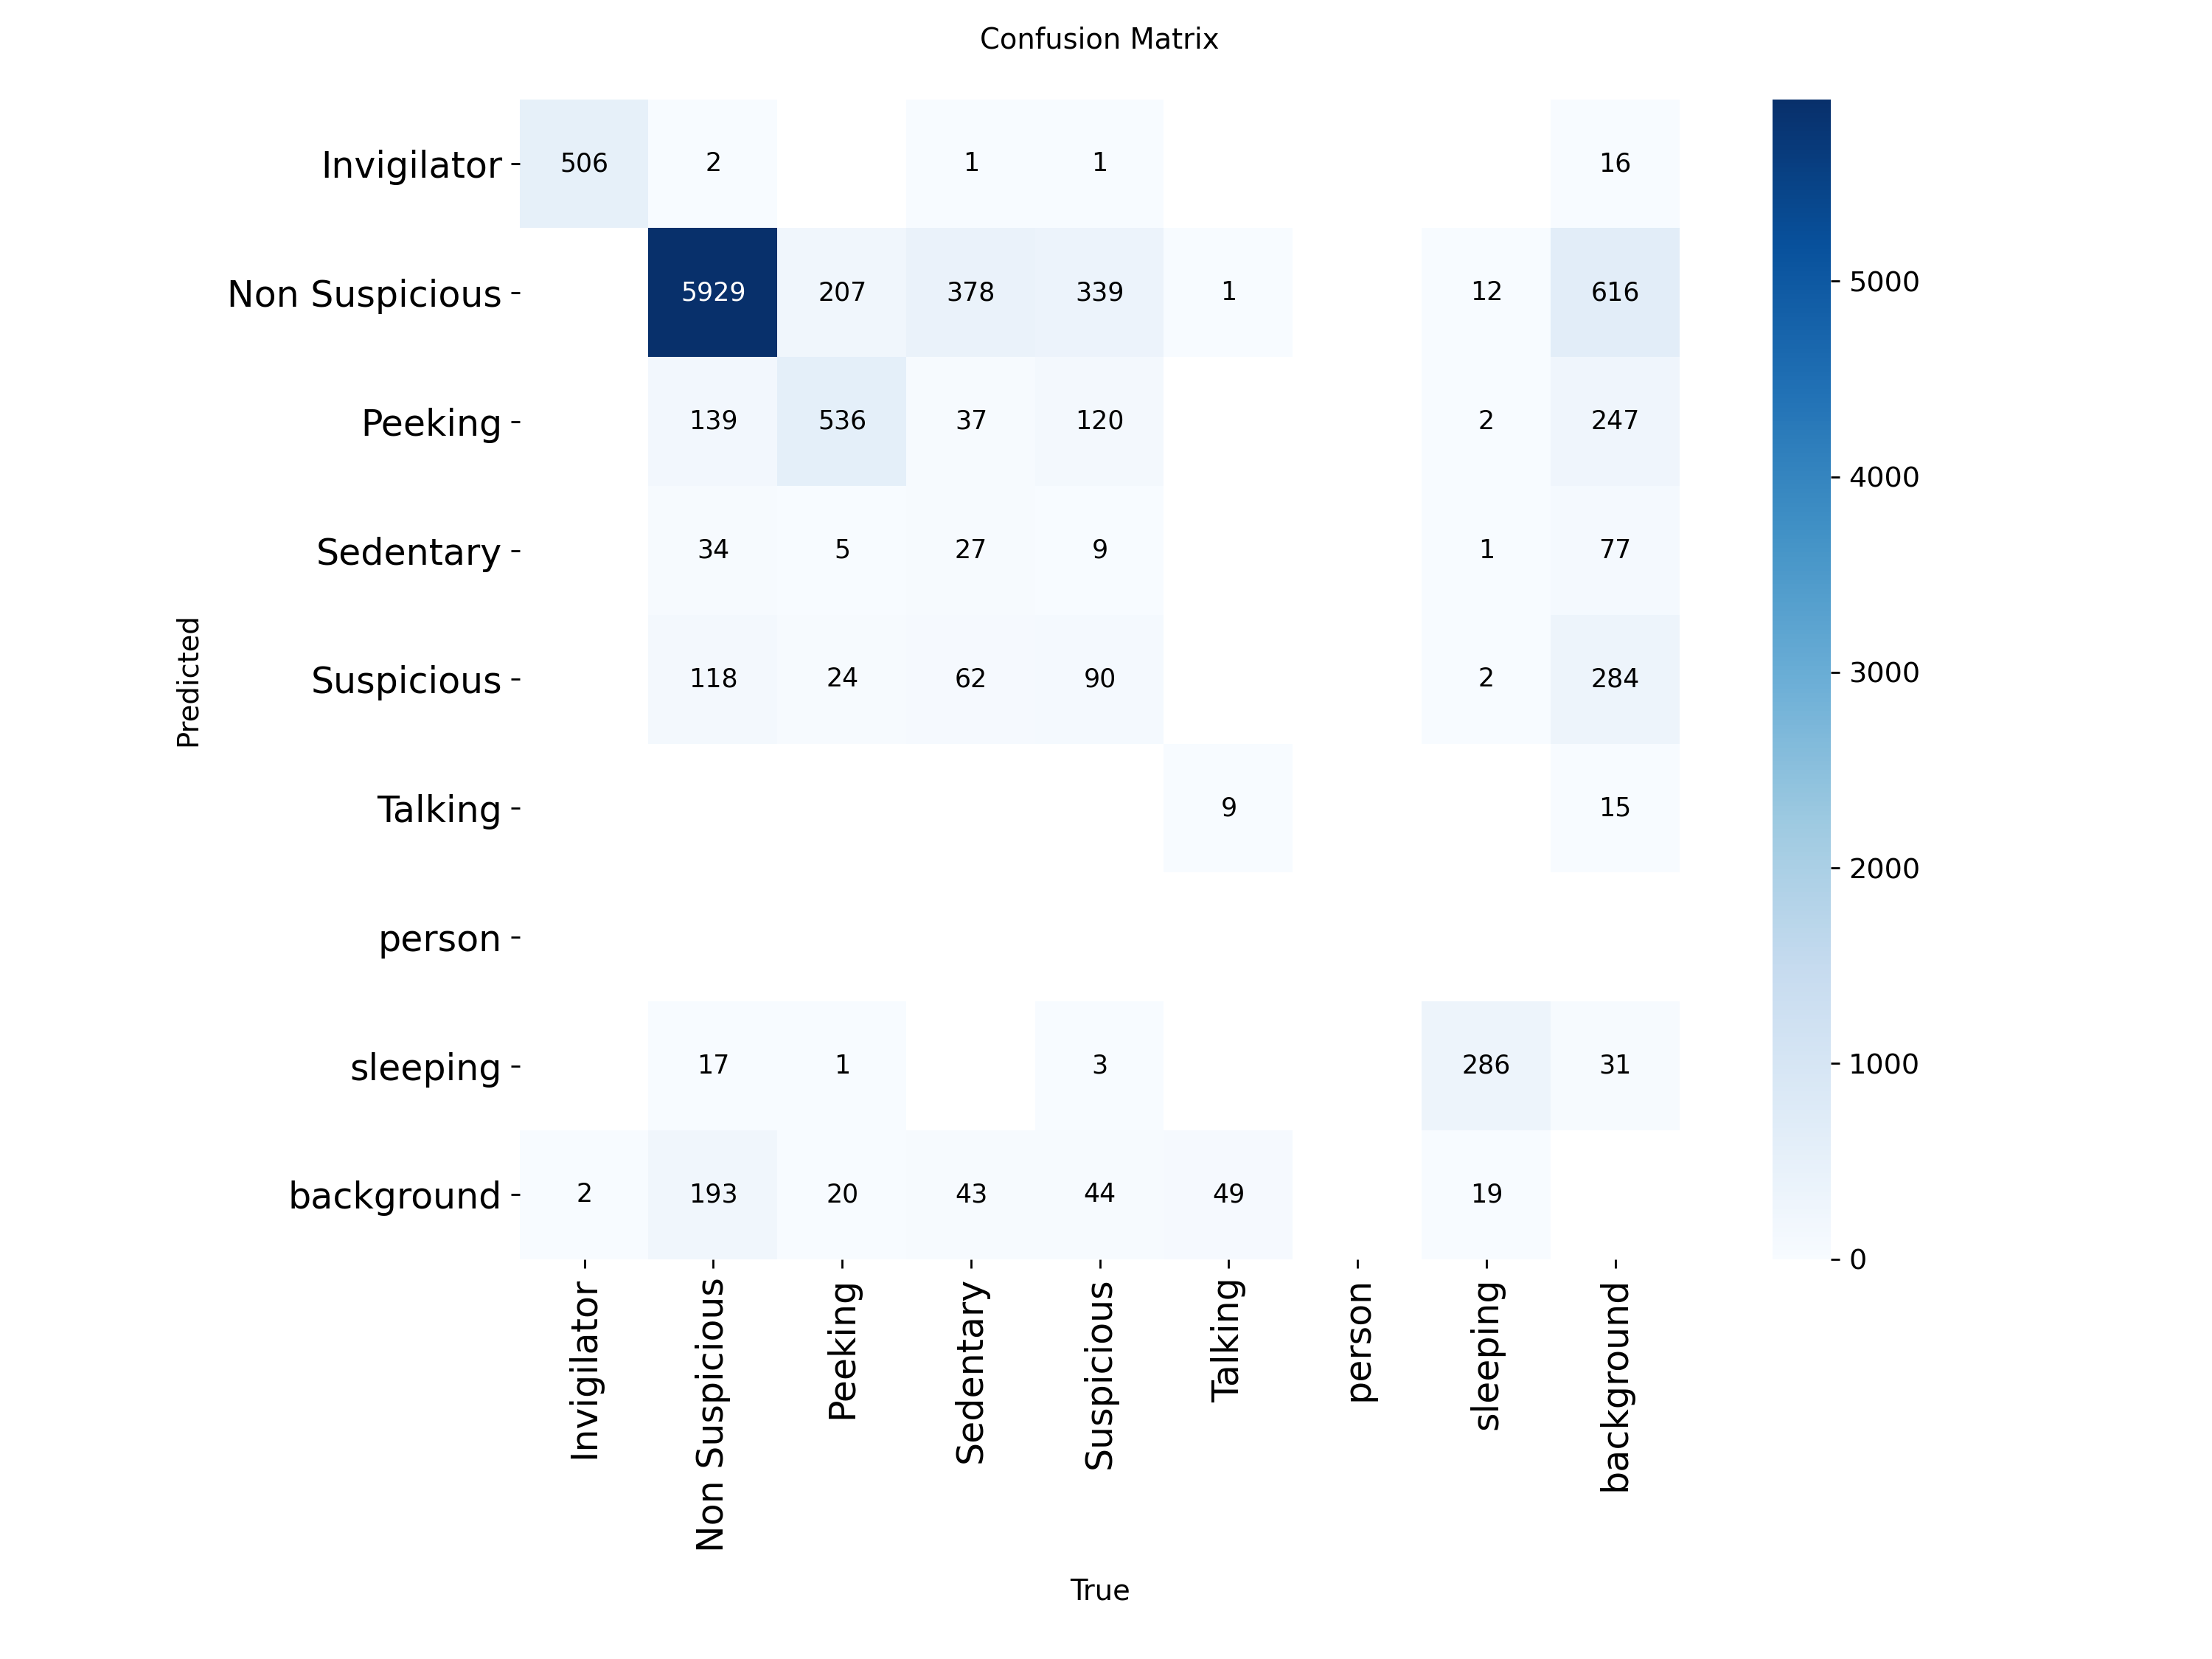

In [20]:
import os
from IPython.display import Image, display

base_path = '/content/runs/detect'

# get latest folder based on modification time
latest_run = max(
    [os.path.join(base_path, d) for d in os.listdir(base_path)],
    key=os.path.getmtime
)

print("Using folder:", latest_run)

display(Image(filename=os.path.join(latest_run, 'results.png')))
display(Image(filename=os.path.join(latest_run, 'confusion_matrix.png')))

FileNotFoundError: [Errno 2] No such file or directory: '/content/runs/detect/exam_dataset/weights/best.pt'

In [25]:
import os
print(os.listdir('/content/runs/detect'))

['invigilo_yolov83', 'predict', 'invigilo_yolov84', 'invigilo_yolov8', 'invigilo_yolov82']


In [26]:
for folder in os.listdir('/content/runs/detect'):
    path = os.path.join('/content/runs/detect', folder, 'weights')
    if os.path.exists(path):
        print(f"\n📁 {folder}/weights:")
        print(os.listdir(path))


📁 invigilo_yolov83/weights:
['best.pt', 'last.pt']

📁 invigilo_yolov84/weights:
['best.pt', 'last.pt']

📁 invigilo_yolov8/weights:
[]

📁 invigilo_yolov82/weights:
[]


In [27]:
from ultralytics import YOLO

model = YOLO('/content/runs/detect/invigilo_yolov83/weights/best.pt')

In [28]:
results = model.predict(
    source='/content/drive/MyDrive/exam_dataset/test/images',
    imgsz=640,
    conf=0.25,
    save=True
)

print("✅ Testing completed!")


image 1/199 /content/drive/MyDrive/exam_dataset/test/images/video_20250926_155125_frame_00001_jpg.rf.ddd0d161e983d8a3a71227e8e7c908b2.jpg: 640x640 12 Non Suspiciouss, 4 Peekings, 5 Sedentarys, 16.2ms
image 2/199 /content/drive/MyDrive/exam_dataset/test/images/video_20250926_155125_frame_00007_jpg.rf.53418de12c4b2d4b4fbfd9876cac5be3.jpg: 640x640 11 Non Suspiciouss, 4 Peekings, 8 Sedentarys, 38.8ms
image 3/199 /content/drive/MyDrive/exam_dataset/test/images/video_20250926_155125_frame_00016_jpg.rf.6a4b6977079fbe67ca43b78af53d0def.jpg: 640x640 1 Invigilator, 18 Non Suspiciouss, 16.3ms
image 4/199 /content/drive/MyDrive/exam_dataset/test/images/video_20250926_155125_frame_00018_jpg.rf.d99f6079ca8c98d57da2351477a8285c.jpg: 640x640 1 Invigilator, 17 Non Suspiciouss, 16.2ms
image 5/199 /content/drive/MyDrive/exam_dataset/test/images/video_20250926_155125_frame_00023_jpg.rf.3e4689f6d87f981103b09fda23fd86c3.jpg: 640x640 1 Invigilator, 16 Non Suspiciouss, 16.2ms
image 6/199 /content/drive/MyDri

In [29]:
!cp /content/runs/detect/invigilo_yolov83/weights/best.pt /content/drive/MyDrive/invigilo_yolov83_best.pt




In [30]:
!ls /content/runs/detect/video_test/

ls: cannot access '/content/runs/detect/video_test/': No such file or directory


In [32]:
!ffmpeg -i /content/runs/detect/video_test/test.avi -vcodec libx264 /content/runs/detect/video_test/test.mp4



ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [38]:
from ultralytics import YOLO

model = YOLO('/content/runs/detect/invigilo_yolov84/weights/best.pt')

In [39]:
from google.colab import files

files.download('/content/runs/detect/invigilo_yolov84/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
import os

print(os.path.exists('/content/runs/detect/invigilo_yolov84/weights/best.pt'))

True
